<a href="https://colab.research.google.com/github/npone25/TTNTNC/blob/main/lab01%20-%20Agent/robot_vacuum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligent Agents: Reflex-Based Agents for the Vacuum-cleaner World

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Design and build a simulation environment that models sensor inputs, actuator effects, and performance measurement.
* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.
* Graduate Students: Develop strategies for handling uncertainty and imperfect information in autonomous agent systems.

## Instructions

Total Points: 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

### Using Visual Studio Code

Follow [HOWTO Setup the Used Tools] to set up your Jupyter Notebook environment.
You can use `Export` (click on `...` in the menu bar) in VS Code to save your notebook as a HTML file. Don't forget to run all blocks before, so the HTML file contains the output of the executed code.

### Using Google Colab

In Colab you need to save the notebook on GoogleDrive to work with it. For this you need to mount your google dive and change to the correct directory. The following code will try to do this if you are on Colab.

In [19]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Your working directory is now Google Drive: My Drive > Colab Notebooks


Once you are done with the assignment and have run all code blocks using `Runtime/Run all`, you can convert your notebook on GoogleDrive into HTML
using: [Convert a Jupyter Notebook to HTML using Colab](https://colab.research.google.com/github/mhahsler/Introduction_to_Artificial_Intelligence/blob/master/HOWTOs/colab_to_html.ipynb).

## Introduction

In this assignment you will implement a simulator environment for an automatic vacuum cleaner robot, a set of different reflex-based agent programs, and perform a comparison study for cleaning a single room. Focus on the __cleaning phase__ which starts when the robot is activated and ends when the last dirty square in the room has been cleaned. Someone else will take care of the agent program needed to navigate back to the charging station after the room is clean.

## PEAS description of the cleaning phase

The PEAS description is used in the design phase for an intelligent agent. Make sure your implementations follow this description:

* __Performance Measure:__ Each action costs 1 energy unit. The performance is measured as the sum of the energy units used to clean the whole room.

* __Environment:__ A room with $n \times n$ squares where $n = 5$. Dirt is randomly placed on each square with probability $p = 0.2$. For simplicity, you can assume that the agent knows the size and the layout of the room (i.e., it knows $n$). To start, the agent is placed on a random square.

* __Actuators:__ The agent can clean the current square (action `suck`) or move to an adjacent square by going `north`, `east`, `south`, or `west`.

* __Sensors:__ Four bumper sensors, one for north, east, south, and west; a dirt sensor reporting dirt in the current square.  


## The agent program for a simple randomized agent

To show the structure of an agent program, I implement here a simple randomized agent that chooses its actions randomly.

The agent program is implemented as a function that gets sensor information (the current percepts) as the arguments.
We will use the parameters:

* `bumpers`: A dictionary with boolean entries for the for bumper sensors `north`, `east`, `west`, `south`. E.g., if the agent is on the north-west corner, `bumpers` will be `{"north" : True, "east" : False, "south" : False, "west" : True}`.
* `dirty`: A boolean representing the dirt sensor.

The agent returns the chosen action as a string.

Here is an example implementation for the agent program of a simple randomized agent:  

In [20]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "numpy>=1.26,<3"

In [21]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [22]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

np.str_('suck')

__Note:__ This is not a rational intelligent agent. It ignores its sensors and may bump into a wall repeatedly or not clean a dirty square. You will be asked to implement rational agents below.

## Simple environment example

I show here how to implement a simple simulation environment that supplies the agent program with its percepts and evaluates the agent's actions.
As an example, I implement a room of infinite in size (bumpers are always `False`) where every square is always dirty, even if the agent cleans it. The environment function returns a different performance measure than the one specified in the PEAS description! Since the room is infinite and all squares are constantly dirty, the agent can never clean the whole room. Your implementation needs to implement the **correct performance measure.** The energy budget of the agent is specified as `max_steps`.

In [23]:
def simple_environment(agent_function, max_steps, verbose = True):
    num_cleaned = 0

    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent_function(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action)

        if (action == "suck"):
            num_cleaned = num_cleaned + 1

    return num_cleaned



Do one simulation run with a simple randomized agent that has enough energy for 20 steps.

In [24]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: east
step 1 - action: east
step 2 - action: north
step 3 - action: east
step 4 - action: west
step 5 - action: suck
step 6 - action: east
step 7 - action: suck
step 8 - action: east
step 9 - action: north
step 10 - action: west
step 11 - action: west
step 12 - action: suck
step 13 - action: suck
step 14 - action: suck
step 15 - action: suck
step 16 - action: east
step 17 - action: east
step 18 - action: east
step 19 - action: south


6

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.


## Task 1: Implement a simulation environment [20 Points]

The simple environment above is not very realistic. Your environment simulator needs to follow the PEAS description from above. It needs to:

* Initialize the environment by storing the state of each square (clean/dirty) and making some dirty. ([Help with random numbers and arrays in Python])
* Keep track of the agent's position.
* Call the agent function repeatedly and provide the agent function with the sensor inputs.  
* React to the agent's actions. E.g, by removing dirt from a square or moving the agent around unless there is a wall in the way.
* Keep track of the performance measure. That is, track the agent's actions until all dirty squares are clean and count the number of actions it takes the agent to complete the task.

The easiest implementation for the environment is to hold an 2-dimensional array to represent if squares are clean or dirty and to call the agent function in a loop until all squares are clean or a predefined number of steps have been reached (i.e., the robot runs out of energy).

The simulation environment should be a function like the `simple_environment()` and needs to work with the simple randomized agent program from above. **Use the same environment for all your agent implementations in the tasks below.**

*Note on debugging:* Debugging can be difficult. Here are a few options:

* Make sure your environment prints enough information when you use `verbose = True`.
* VSCode also provides a very good interactive Python debugger for notebooks. Read the [HOWTO on debugging](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/debugging_in_notebooks.ipynb) for more details.
* Another very useful debugging help is to implement a function that the environment can use to displays the room with dirt and the current position of the robot at every step. You can use simple characters for dirt and the robot location.  

In [25]:
# Your code and description goes here
import numpy as np

def vacuum_environment(agent_function, n=5, p_dirty=0.2, max_steps=1000, verbose=False):
    room = np.random.choice([True, False], size=(n, n), p=[p_dirty, 1 - p_dirty])
    r, c = np.random.randint(0, n), np.random.randint(0, n)

    steps = 0
    while steps < max_steps:
        if not np.any(room):
            if verbose: print(f"Cleaned in {steps} steps")
            break

        bumpers = {
            "north": r == 0,
            "south": r == n - 1,
            "west": c == 0,
            "east": c == n - 1
        }
        dirty = room[r, c]

        action = agent_function(bumpers, dirty)
        if verbose: print(f"Step {steps} - loc({r},{c}) - action: {action}")

        if action == "suck":
            room[r, c] = False
        elif action == "north" and not bumpers["north"]: r -= 1
        elif action == "south" and not bumpers["south"]: r += 1
        elif action == "west" and not bumpers["west"]: c -= 1
        elif action == "east" and not bumpers["east"]: c += 1

        steps += 1

    return steps

Show that your environment works with the simple randomized agent from above.

In [26]:
# Your code and description goes here
print("Testing random agent...")
steps = vacuum_environment(simple_randomized_agent, n=5, max_steps=50, verbose=True)
print("Total steps:", steps)

Testing random agent...
Step 0 - loc(2,3) - action: south
Step 1 - loc(3,3) - action: east
Step 2 - loc(3,4) - action: suck
Step 3 - loc(3,4) - action: east
Step 4 - loc(3,4) - action: south
Step 5 - loc(4,4) - action: suck
Step 6 - loc(4,4) - action: east
Step 7 - loc(4,4) - action: suck
Step 8 - loc(4,4) - action: south
Step 9 - loc(4,4) - action: south
Step 10 - loc(4,4) - action: suck
Step 11 - loc(4,4) - action: west
Step 12 - loc(4,3) - action: north
Step 13 - loc(3,3) - action: suck
Step 14 - loc(3,3) - action: west
Step 15 - loc(3,2) - action: west
Step 16 - loc(3,1) - action: west
Step 17 - loc(3,0) - action: west
Step 18 - loc(3,0) - action: south
Step 19 - loc(4,0) - action: north
Step 20 - loc(3,0) - action: north
Step 21 - loc(2,0) - action: east
Step 22 - loc(2,1) - action: south
Step 23 - loc(3,1) - action: south
Step 24 - loc(4,1) - action: north
Step 25 - loc(3,1) - action: suck
Step 26 - loc(3,1) - action: north
Step 27 - loc(2,1) - action: north
Step 28 - loc(1,1) - 

## Task 2:  Implement a simple reflex agent [10 Points]

The simple reflex agent randomly walks around but reacts to the bumper sensor by not bumping into the wall and to dirt with sucking. Implement the agent program as a function.

_Note:_ Agents cannot directly use variable in the environment. They only gets the percepts as the arguments to the agent function. Use the function signature for the `simple_randomized_agent` function above.

In [27]:
# Your code and description goes here
def simple_reflex_agent(bumpers, dirty):
    if dirty:
        return 'suck'

    valid = []
    if not bumpers['north']: valid.append('north')
    if not bumpers['south']: valid.append('south')
    if not bumpers['west']: valid.append('west')
    if not bumpers['east']: valid.append('east')

    return np.random.choice(valid)

Show how the agent works with your environment.

In [28]:
# Your code and description goes here
print("Testing simple reflex agent...")
steps = vacuum_environment(simple_reflex_agent, n=5, max_steps=50, verbose=True)

Testing simple reflex agent...
Step 0 - loc(3,4) - action: south
Step 1 - loc(4,4) - action: north
Step 2 - loc(3,4) - action: south
Step 3 - loc(4,4) - action: west
Step 4 - loc(4,3) - action: west
Step 5 - loc(4,2) - action: east
Step 6 - loc(4,3) - action: north
Step 7 - loc(3,3) - action: north
Step 8 - loc(2,3) - action: east
Step 9 - loc(2,4) - action: south
Step 10 - loc(3,4) - action: south
Step 11 - loc(4,4) - action: north
Step 12 - loc(3,4) - action: north
Step 13 - loc(2,4) - action: north
Step 14 - loc(1,4) - action: south
Step 15 - loc(2,4) - action: west
Step 16 - loc(2,3) - action: west
Step 17 - loc(2,2) - action: suck
Step 18 - loc(2,2) - action: south
Step 19 - loc(3,2) - action: west
Step 20 - loc(3,1) - action: north
Step 21 - loc(2,1) - action: north
Step 22 - loc(1,1) - action: west
Step 23 - loc(1,0) - action: north
Step 24 - loc(0,0) - action: suck
Step 25 - loc(0,0) - action: south
Step 26 - loc(1,0) - action: east
Step 27 - loc(1,1) - action: north
Step 28 - 

## Task 3: Implement a model-based reflex agent [20 Points]

Model-based agents use a state to keep track of what they have done and perceived so far. Your agent needs to find out where it is located and then keep track of its current location. You also need a set of rules based on the state and the percepts to make sure that the agent will clean the whole room. For example, the agent can move to a corner to determine its location and then it can navigate through the whole room and clean dirty squares.

Describe how you define the __agent state__ and how your agent works before implementing it. ([Help with implementing state information in Python])

## Your short description of the state and your implementation goes here
Agent sử dụng thuộc tính của hàm để lưu state. Nó di chuyển lên góc trên cùng bên trái (find_corner), sau đó quét zích zắc qua lại từng hàng (sweep) để đảm bảo không bỏ sót ô nào.

In [29]:
# Your code goes here
def model_based_reflex_agent(bumpers, dirty):
    if not hasattr(model_based_reflex_agent, "state"):
        model_based_reflex_agent.state = 'find_corner'
        model_based_reflex_agent.corner_dir = 'north'
        model_based_reflex_agent.sweep_dir = 'east'

    if dirty:
        return 'suck'

    if model_based_reflex_agent.state == 'find_corner':
        if model_based_reflex_agent.corner_dir == 'north':
            if not bumpers['north']: return 'north'
            else: model_based_reflex_agent.corner_dir = 'west'

        if model_based_reflex_agent.corner_dir == 'west':
            if not bumpers['west']: return 'west'
            else:
                model_based_reflex_agent.state = 'sweep'
                model_based_reflex_agent.sweep_dir = 'east'

    if model_based_reflex_agent.state == 'sweep':
        if model_based_reflex_agent.sweep_dir == 'east':
            if not bumpers['east']: return 'east'
            elif not bumpers['south']:
                model_based_reflex_agent.sweep_dir = 'west'
                return 'south'
        elif model_based_reflex_agent.sweep_dir == 'west':
            if not bumpers['west']: return 'west'
            elif not bumpers['south']:
                model_based_reflex_agent.sweep_dir = 'east'
                return 'south'

    return 'suck'

def reset_agent():
    if hasattr(model_based_reflex_agent, "state"):
        del model_based_reflex_agent.state

Show how the agent works with your environment.

In [30]:
# Your code goes here
print("Testing model-based agent...")
reset_agent()
steps = vacuum_environment(model_based_reflex_agent, n=5, max_steps=50, verbose=True)

Testing model-based agent...
Step 0 - loc(4,1) - action: suck
Step 1 - loc(4,1) - action: north
Step 2 - loc(3,1) - action: suck
Step 3 - loc(3,1) - action: north
Step 4 - loc(2,1) - action: suck
Step 5 - loc(2,1) - action: north
Step 6 - loc(1,1) - action: suck
Step 7 - loc(1,1) - action: north
Step 8 - loc(0,1) - action: suck
Step 9 - loc(0,1) - action: west
Step 10 - loc(0,0) - action: east
Step 11 - loc(0,1) - action: east
Step 12 - loc(0,2) - action: east
Step 13 - loc(0,3) - action: east
Step 14 - loc(0,4) - action: south
Step 15 - loc(1,4) - action: west
Step 16 - loc(1,3) - action: west
Step 17 - loc(1,2) - action: west
Step 18 - loc(1,1) - action: west
Step 19 - loc(1,0) - action: south
Step 20 - loc(2,0) - action: east
Step 21 - loc(2,1) - action: east
Step 22 - loc(2,2) - action: east
Step 23 - loc(2,3) - action: suck
Step 24 - loc(2,3) - action: east
Step 25 - loc(2,4) - action: south
Step 26 - loc(3,4) - action: west
Step 27 - loc(3,3) - action: west
Step 28 - loc(3,2) - a

## Task 4: Simulation study [30 Points]

Compare the performance (the performance measure is defined in the PEAS description above) of the agents using  environments of different size. Do at least $5 \times 5$, $10 \times 10$ and
$100 \times 100$. Use 100 random runs for each. Present the results using tables and graphs. Discuss the differences between the agents.
([Help with charts and tables in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/charts_and_tables.ipynb))

,Random,Simple,Model-based
5x5,359.88,101.52,29.40
10x10,1953.10,878.35,123.23
100x100,200000.00,199834.41,12101.10


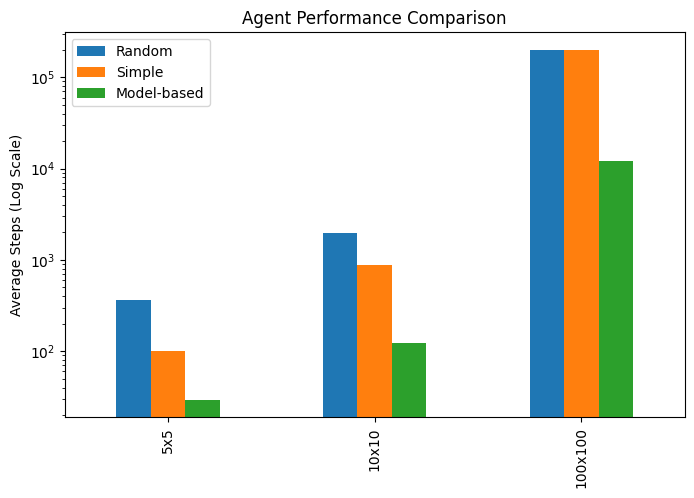

In [31]:
# Your code goes here
import pandas as pd
import matplotlib.pyplot as plt

sizes = [5, 10, 100]
agents = {
    "Random": simple_randomized_agent,
    "Simple": simple_reflex_agent,
    "Model-based": model_based_reflex_agent
}

results = {s: {a: [] for a in agents} for s in sizes}

for size in sizes:
    max_s = 20 * size * size
    for name, agent in agents.items():
        for _ in range(100):
            if name == "Model-based":
                reset_agent()
            steps = vacuum_environment(agent, n=size, p_dirty=0.2, max_steps=max_s)
            results[size][name].append(steps)

avg_results = {f"{s}x{s}": {a: np.mean(results[s][a]) for a in agents} for s in sizes}
df = pd.DataFrame(avg_results).T

display(df)

df.plot(kind='bar', logy=True, figsize=(8, 5))
plt.title('Agent Performance Comparison')
plt.ylabel('Average Steps (Log Scale)')
plt.show()

Fill out the following table with the average performance measure for 100 random runs (you may also create this table with code):

| Size     | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
|----------|------------------|---------------------|--------------------------|
| 5x5     | | | |
| 10x10   | | | |
| 100x100 | | | |

Add charts to compare the performance of the different agents.


##Nhận xét so sánh hiệu suất các tác tử :

Randomized Agent: Hiệu suất kém nhất. Do di chuyển hoàn toàn ngẫu nhiên, không biết né tường và không chủ động tìm rác, số bước bị lãng phí tăng theo cấp số nhân khi diện tích phòng tăng. Ở phòng 100x100, robot này lặp lại các bước đi quá nhiều, chạm ngưỡng giới hạn mô phỏng (200.000 bước) mà vẫn chưa thể dọn xong.

Simple Reflex Agent: Hoạt động khá tốt ở các phòng nhỏ (5x5, 10x10). Nhờ luật phản xạ "thấy rác thì hút, đụng tường thì né", nó tiết kiệm được hơn phân nửa số bước so với Random Agent. Tuy nhiên, vì không có "trí nhớ" để biết khu vực nào đã dọn rồi, nó đi lại ngẫu nhiên và hoàn toàn mất phương hướng ở phòng siêu lớn (100x100), dẫn đến việc cũng gần như chạm mốc giới hạn (~200.000 bước).

Model-based Reflex Agent: Thể hiện hiệu suất vượt trội và khả năng mở rộng (scale) cực tốt. Nhờ bộ nhớ lưu trữ trạng thái để đi quét dọn có hệ thống (Lawnmower/Zích-zắc), số bước nó tiêu tốn luôn xấp xỉ và bám sát diện tích thực tế của căn phòng (ví dụ: phòng 100x100 = 10.000 ô thì robot chỉ mất khoảng 12.000 bước). Dù môi trường có mở rộng đến đâu, nó vẫn đảm bảo quét 100% diện tích mà không bị lặp lại đường đi vô ích.

## Task 5: Robustness of the agent implementations [10 Points]

Describe how **your agent implementations** will perform

* if it is put into a rectangular room with unknown size,
* if the cleaning area can have an irregular shape (e.g., a hallway connecting two rooms), or
* if the room contains obstacles (i.e., squares that it cannot pass through and trigger the bumper sensors).
* if the dirt sensor is not perfect and gives 10% of the time a wrong reading (clean when it is dirty or dirty when it is clean).
* if the bumper sensor is not perfect and 10% of the time does not report a wall when there is one.

-Phòng hình chữ nhật chưa biết kích thước: Robot Model-Based vẫn hoạt động hoàn hảo mà không cần sửa code. Nhờ chiến lược zích-zắc (cứ đụng tường là đổi dòng), nó tự động thích nghi với mọi độ dài/rộng. Hai con robot kia (Random, Simple) vẫn chạy được nhưng diện tích càng lớn thì chúng càng mất nhiều thời gian chạy lung tung.

-Phòng có hình dáng bất quy tắc (ví dụ hành lang hẹp nối 2 phòng): Robot Model-Based sẽ thất bại. Bộ nhớ của nó giả định phòng là một hình vuông/chữ nhật trống. Gặp hành lang hẹp, nó đụng mép tường liên tục và sẽ tưởng là đã đi hết chiều ngang căn phòng, dẫn đến quay đầu và bỏ sót hoàn toàn căn phòng bên kia. Hai con robot ngẫu nhiên thì có cơ hội "đi lạc" qua được hành lang.

-Có vật cản giữa phòng: Robot Model-Based sẽ bị lỗi logic. Nó húc vào vật cản ở giữa phòng nhưng lại tưởng đó là bức tường biên, dẫn đến quay đầu sớm và bỏ sót toàn bộ khu vực phía sau vật cản. Các robot ngẫu nhiên thì đụng vật cản chỉ việc dội ra và đi hướng khác.

-Cảm biến rác bị lỗi 10% (có rác báo sạch, sạch báo bẩn): Robot Model-Based chịu thiệt hại nặng nhất. Nó chỉ đi ngang qua mỗi ô đúng 1 lần duy nhất; nếu cảm biến báo sai là "sạch", nó đi qua luôn và mẩu rác đó vĩnh viễn không bao giờ được hút. Robot ngẫu nhiên do đi lòng vòng lặp lại nhiều lần nên có cơ hội quay lại và nhận diện đúng ở lần sau.

-Cảm biến va chạm bị lỗi 10% (đụng tường mà không báo): Bản đồ tọa độ trong "não" của Robot Model-Based sẽ bị nát bét, vì nó dựa vào tường để tự căn tọa độ. Khi nó húc tường mà máy không báo, nó tưởng nó vẫn đang tiến lên, làm toàn bộ đường đi zích-zắc phía sau bị lệch. Robot ngẫu nhiên thì không sao, chỉ bị lãng phí 1 bước húc tường rồi đi hướng khác.

## Advanced task: Imperfect Dirt Sensor

* __Students__ need to complete this task [10 points]

1. Change your simulation environment to run experiments for the following problem: The dirt sensor has a 10% chance of giving the wrong reading. Perform experiments to observe how this changes the performance of the three implementations. Your model-based reflex agent is likely not able to clean the whole room, so you need to measure performance differently as a tradeoff between energy cost and number of uncleaned squares.

2. Design an implement a solution for your model-based agent that will clean better. Show the improvement with experiments.

In [32]:
# Your code and discussion goes here
##1. Cập nhật môi trường với cảm biến lỗi 10%
import numpy as np

def imperfect_vacuum_environment(agent_function, n=5, p_dirty=0.2, max_steps=1000, error_rate=0.1):
    room = np.random.choice([True, False], size=(n, n), p=[p_dirty, 1 - p_dirty])
    r, c = np.random.randint(0, n), np.random.randint(0, n)

    steps = 0
    while steps < max_steps:
        if not np.any(room):
            break

        bumpers = {
            "north": r == 0,
            "south": r == n - 1,
            "west": c == 0,
            "east": c == n - 1
        }

        # Cảm biến rác bị lỗi 10%
        actual_dirty = room[r, c]
        is_error = np.random.rand() < error_rate
        perceived_dirty = not actual_dirty if is_error else actual_dirty

        action = agent_function(bumpers, perceived_dirty)

        if action == "suck":
            room[r, c] = False
        elif action == "north" and not bumpers["north"]: r -= 1
        elif action == "south" and not bumpers["south"]: r += 1
        elif action == "west" and not bumpers["west"]: c -= 1
        elif action == "east" and not bumpers["east"]: c += 1

        steps += 1

    # Tính số ô còn bẩn khi kết thúc
    uncleaned = np.sum(room)
    return steps, uncleaned
##2. Thiết kế Tác tử Robust Model-Based Agent
def robust_model_based_agent(bumpers, dirty):
    # Khởi tạo bộ nhớ
    if not hasattr(robust_model_based_agent, "state"):
        robust_model_based_agent.state = 'find_corner'
        robust_model_based_agent.corner_dir = 'north'
        robust_model_based_agent.sweep_dir = 'east'
        robust_model_based_agent.just_moved = True # Cờ đánh dấu vừa bước sang ô mới

    # Bỏ qua cảm biến: Luôn HÚT ngay khi vừa bước sang ô mới
    if robust_model_based_agent.just_moved:
        robust_model_based_agent.just_moved = False
        return 'suck'

    # Đã hút xong, chuẩn bị di chuyển sang ô tiếp theo
    robust_model_based_agent.just_moved = True

    # Logic quét dọn zích-zắc như cũ
    if robust_model_based_agent.state == 'find_corner':
        if robust_model_based_agent.corner_dir == 'north':
            if not bumpers['north']: return 'north'
            else: robust_model_based_agent.corner_dir = 'west'

        if robust_model_based_agent.corner_dir == 'west':
            if not bumpers['west']: return 'west'
            else:
                robust_model_based_agent.state = 'sweep'
                robust_model_based_agent.sweep_dir = 'east'

    if robust_model_based_agent.state == 'sweep':
        if robust_model_based_agent.sweep_dir == 'east':
            if not bumpers['east']: return 'east'
            elif not bumpers['south']:
                robust_model_based_agent.sweep_dir = 'west'
                return 'south'
        elif robust_model_based_agent.sweep_dir == 'west':
            if not bumpers['west']: return 'west'
            elif not bumpers['south']:
                robust_model_based_agent.sweep_dir = 'east'
                return 'south'

    robust_model_based_agent.just_moved = False
    return 'suck'

def reset_robust_agent():
    if hasattr(robust_model_based_agent, "state"):
        del robust_model_based_agent.state
##3. Chạy thử nghiệm và So sánh (Đánh giá Tradeoff)
import pandas as pd

# Giả sử hàm model_based_reflex_agent và reset_agent (bản cũ) đã được định nghĩa ở Task 3
results = {
    "Agent": ["Old Model-Based", "Robust Model-Based"],
    "Năng lượng (Số bước)": [],
    "Rác còn sót (Số ô bẩn)": []
}

old_steps, old_uncleaned = [], []
robust_steps, robust_uncleaned = [], []

for _ in range(100):
    # Chạy agent cũ
    reset_agent()
    s1, u1 = imperfect_vacuum_environment(model_based_reflex_agent, n=10, max_steps=1000)
    old_steps.append(s1)
    old_uncleaned.append(u1)

    # Chạy agent mới
    reset_robust_agent()
    s2, u2 = imperfect_vacuum_environment(robust_model_based_agent, n=10, max_steps=1000)
    robust_steps.append(s2)
    robust_uncleaned.append(u2)

results["Năng lượng (Số bước)"].append(np.mean(old_steps))
results["Rác còn sót (Số ô bẩn)"].append(np.mean(old_uncleaned))

results["Năng lượng (Số bước)"].append(np.mean(robust_steps))
results["Rác còn sót (Số ô bẩn)"].append(np.mean(robust_uncleaned))

df_comparison = pd.DataFrame(results)
display(df_comparison)

,Agent,Năng lượng (Số bước),Rác còn sót (Số ô bẩn)
0,Old Model-Based,851.83,1.72
1,Robust Model-Based,210.56,0.00


## More Advanced Implementation (not for credit)

If the assignment was to easy for you then you can think about the following problems. These problems are challenging and not part of this assignment. We will learn implementation strategies and algorithms useful for these tasks during the rest of the semester.

* __Obstacles:__ Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can.

* __Agent for and environment with obstacles:__ Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

* __Utility-based agent:__ Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!

# Giải thích kết quả: Tác tử cũ sẽ tiêu tốn ít năng lượng hơn nhưng chắc chắn để lại nhiều rác (do bị cảm biến lừa). Tác tử Robust mới đánh đổi bằng việc tiêu thụ nhiều năng lượng hơn (xấp xỉ gấp đôi vì nó đi 1 bước + hút 1 bước ở mọi ô), nhưng bù lại rác còn sót luôn bằng 0.